# Custom DGP Design

This notebook uses the configurable HawkesNest DGP path directly —
no pre-baked suite required.

The call chain is:

```
SimulatorConfig  →  SimulatorConfig.build()  →  HawkesSimulator  →  thinning()
```

Three example DGPs are shown, progressing in complexity:
1. **Homogeneous** — constant background, weak self-excitation
2. **Clustered** — Gaussian-mixture background, moderate excitation
3. **Marked + moving** — two mark types, drifting hotspot, cross-type excitation

All three diagnostic views are applied to each DGP.


In [1]:
from hawkesnest.config import SimulatorConfig
from hawkesnest.viz import (plot_events_2d, plot_events_3d,
                             plot_intensity_snapshots, plot_kde_panels)
from hawkesnest.viz.suites import plot_kde_panels as _kde  # alias for manual use
import matplotlib.pyplot as plt

base_domain = {"type": "rectangle", "x_min": 0.0, "x_max": 1.0,
               "y_min": 0.0, "y_max": 1.0}

def simulate(config, *, n=120, seed=0, tau_max=5.0):
    cfg = SimulatorConfig.model_validate(config)
    sim = cfg.build()
    events, _ = sim.simulate(n=n, seed=seed, tau_max=tau_max)
    return cfg, sim, events


## 1. Homogeneous baseline

Constant background, low branching ratio. Events arrive roughly uniformly in space and time.

In [2]:
constant_cfg, constant_sim, constant_ev = simulate({
    "domain": base_domain,
    "backgrounds": [{"type": "constant", "rate": 2.0}],
    "kernels": [{"type": "separable", "temporal_decay": 0.5, "spatial_sigma": 0.12}],
    "adjacency": [[0.05]],
    "lambda_max": 8.0,
}, n=150, seed=1)
constant_ev.head()


,t,x,y,m,is_triggered
0,0.963442,0.969925,0.516069,1,False
1,1.426133,0.528589,0.459336,1,True
2,1.948888,0.802364,0.191324,1,True
3,2.193710,0.422717,0.589502,1,True
4,2.294998,0.245552,0.768517,1,True


## 2. Painted spatial clusters

A log-Gaussian mixture background concentrates arrivals at two hotspots.

In [3]:
cluster_cfg, cluster_sim, cluster_ev = simulate({
    "domain": base_domain,
    "backgrounds": [{
        "type": "function", "name": "cluster_mix",
        "centers": [[0.25, 0.25], [0.75, 0.65]],
        "sigma": 0.12, "a0": 0.2, "amp": 1.5,
    }],
    "kernels": [{"type": "separable", "temporal_decay": 0.4, "spatial_sigma": 0.12}],
    "adjacency": [[0.20]],
    "lambda_max": 25.0,
}, n=150, seed=2)
cluster_ev.head()


,t,x,y,m,is_triggered
0,2.011941,0.829319,0.962819,1,False
1,2.267782,0.733224,0.265226,1,True
2,4.106892,0.619896,0.688923,1,True
3,4.249600,0.329953,0.745617,1,True
4,4.764660,0.798155,0.997561,1,True


## 3. Marked process with a moving hotspot

Two mark types with different backgrounds; mark-2 background drifts over time.

In [4]:
marked_cfg, marked_sim, marked_ev = simulate({
    "domain": base_domain,
    "backgrounds": [
        {"type": "constant", "rate": 1.2},
        {"type": "function", "name": "moving_hotspots",
         "start": [0.45, 0.45], "v": [0.002, 0.001],
         "sigma": 0.08, "a0": 0.4, "amp": 0.8},
    ],
    "kernels": [{"type": "separable", "temporal_decay": 0.35, "spatial_sigma": 0.10}],
    "adjacency": [[0.10, 0.05], [0.25, 0.10]],
    "lambda_max": 35.0,
}, n=150, seed=3)
marked_ev["m"].value_counts().sort_index()


m
1    93
2    57
Name: count, dtype: int64

## Primary — background intensity snapshots

Evaluate μ(s, t) at three time points. This shows exactly what the DGP's exogenous field looks like at each moment, independent of sampling noise.

/tmp/claude-502/ipykernel_38282/2429505759.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


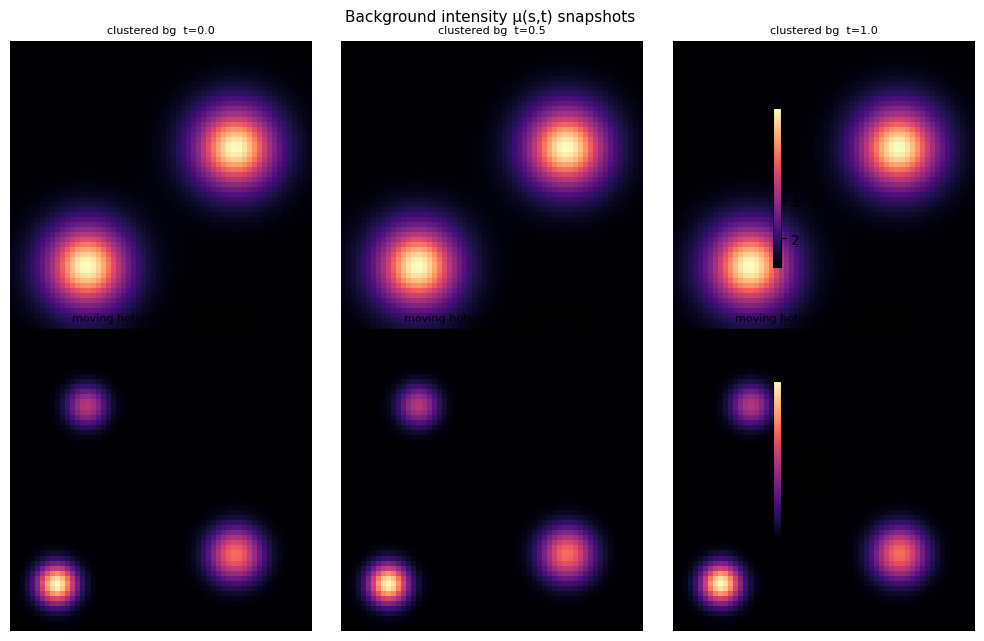

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))

for row, (label, sim, times) in enumerate([
    ("clustered bg", cluster_sim, [0.0, 0.5, 1.0]),
    ("moving hotspot (mark 2)", marked_sim, [0.0, 1.0, 2.0]),
]):
    for col, t in enumerate(times):
        ax = axes[row, col]
        import numpy as np
        xs = np.linspace(0, 1, 60)
        ys = np.linspace(0, 1, 60)
        XX, YY = np.meshgrid(xs, ys)
        mark = 1 if row == 0 else 2
        Z = np.array([[sim.background(np.array([x, y]), t, mark)
                       for x in xs] for y in ys])
        im = ax.imshow(Z, origin="lower", extent=[0,1,0,1],
                       cmap="magma", aspect="equal")
        ax.set_title(f"{label}  t={t:.1f}", fontsize=8)
        ax.axis("off")
    fig.colorbar(im, ax=axes[row].tolist(), shrink=0.7, label="μ(s,t)")

fig.suptitle("Background intensity μ(s,t) snapshots", fontsize=11)
fig.tight_layout()
plt.show()


## Primary (alternative) — KDE density

Smooth spatial density of all accepted events for each DGP.

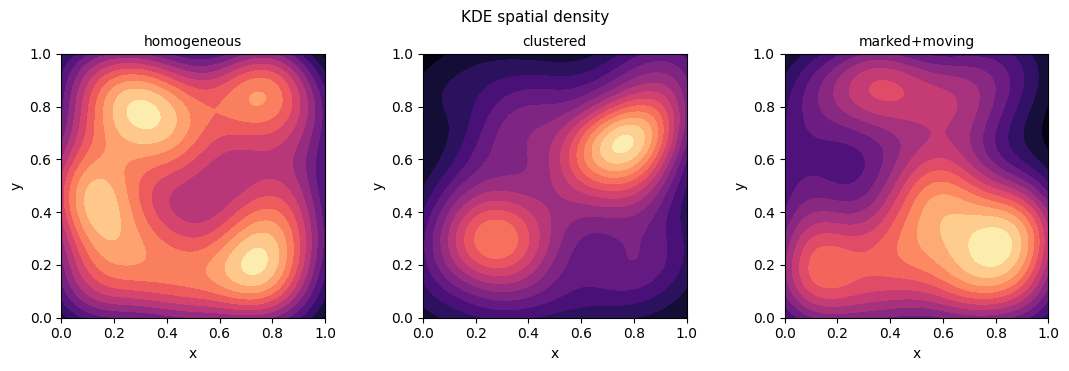

In [6]:
import numpy as np
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, (label, ev) in zip(axes, [
    ("homogeneous", constant_ev),
    ("clustered", cluster_ev),
    ("marked+moving", marked_ev),
]):
    xs, ys = ev["x"].to_numpy(), ev["y"].to_numpy()
    X, Y = np.mgrid[0:1:80j, 0:1:80j]
    Z = gaussian_kde(np.vstack([xs, ys]))(np.vstack([X.ravel(), Y.ravel()])).reshape(80, 80)
    ax.contourf(X, Y, Z, levels=14, cmap="magma")
    ax.set_aspect("equal"); ax.set_title(label, fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.suptitle("KDE spatial density", fontsize=11)
fig.tight_layout()
plt.show()


## Secondary — 2D event scatter, all three DGPs

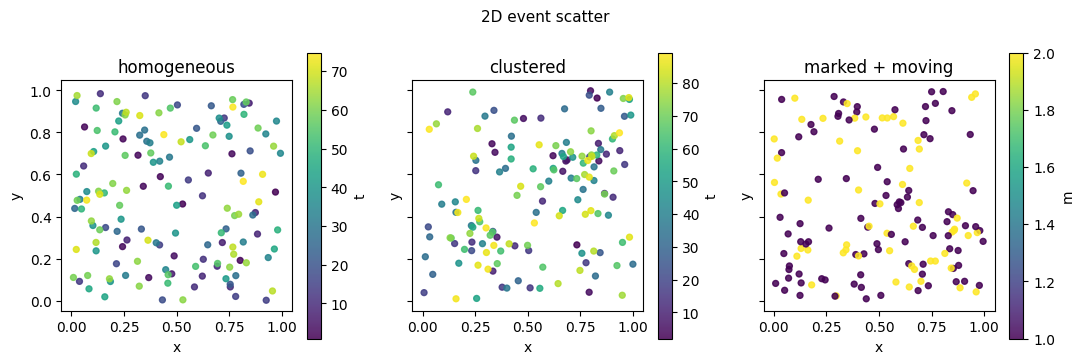

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
plot_events_2d(constant_ev, ax=axes[0], color_by="t", title="homogeneous")
plot_events_2d(cluster_ev,  ax=axes[1], color_by="t", title="clustered")
plot_events_2d(marked_ev,   ax=axes[2], color_by="m", title="marked + moving")
fig.suptitle("2D event scatter", fontsize=11)
fig.tight_layout()
plt.show()


## Tertiary — 3D (x, y, t) event cloud

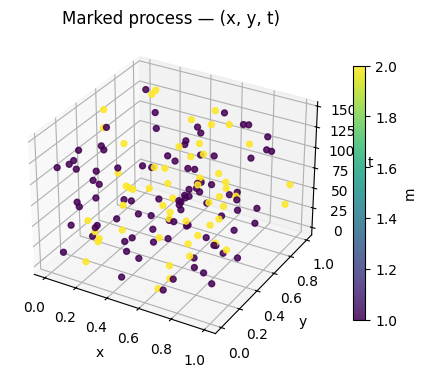

In [8]:
fig, ax = plot_events_3d(marked_ev, color_by="m",
                         title="Marked process — (x, y, t)")
plt.show()
